# **Homework2-2 - Latent Diffusion Model**

This is the sample code of homework 2-2 of the IMVFX course by Prof. I-Chen Lin.

In this section, you are required to build a conditional latent diffusion model (cLDM) with a VAE encoder/decoder and a diffusion model in the latent space.

If you have any questions, please contact the TA via jeffbla.cs14@nycu.edu.tw


Sample code for LDM, including the VAE + latent diffusion structure and training function. You can start from this file or write your own structure and train function. You can also modify anything in this file for training except the function of FID.

What you need to do:
1. Load MNIST dataset.
2. Train the VAE
3. Plot the loss of VAE.
4. Train the LDM and generate images in 5*5 grid.
5. Plot the loss of LDM.
6. Load the CelebA dataset.
7. Design the LDM process for the CelebA dataset and perform the same steps as in step 2 ~ 5.

# Set up the environment


### Packages Installation


In [ ]:
# Libraries for handling tensor operations and visualization
!pip install einops tqdm imageio torchmetrics gdown torch-fidelity

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.8 MB/s eta 0:00:00


### Download the dataset


For the tutorial section, you need to use the MNIST and CelebA dataset in torchvision.
Torchvision will handle the download for MINST. But for celeba_dataset, the download link in google drive is locked. We need to handle by ourself and load following the torchvision guidance.


In [2]:
!gdown 1rV0NoenLMBoFRVC3fD92s_CSBhBDh_bc -O celeba_dataset.zip

Downloading...
From (original): https://drive.google.com/uc?id=1rV0NoenLMBoFRVC3fD92s_CSBhBDh_bc
From (redirected): https://drive.google.com/uc?id=1rV0NoenLMBoFRVC3fD92s_CSBhBDh_bc&confirm=t&uuid=5bf5dedd-1b32-4744-ac4b-e84e23738830
To: /ssd/jasonzzz/NYCU_2026_spring/IMVFX/hw2_2/celeba_dataset.zip
100%|██████████████████████████████████████| 2.88G/2.88G [00:38<00:00, 74.7MB/s]


In [3]:
!unzip -q celeba_dataset.zip

# Random seed


In [1]:
# You may replace the workspace directory if you want
workspace_dir = '.'
import random

import torch
import numpy as np

def same_seeds(seed):
  # Python built-in random module
  random.seed(seed)
  # Numpy
  np.random.seed(seed)
  # Torch
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.benchmark = False
  torch.backends.cudnn.deterministic = True

# Set random seed for reproducibility
same_seeds(999)

# Import packages


In [2]:
import math
import os
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple, Literal

import imageio
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
import torchvision
from torchvision.transforms import Compose, ToTensor, Lambda, Grayscale, Resize
from torchvision.utils import make_grid, save_image
from tqdm import tqdm

# Hyperparameters and Initialization


**VRAM note:** MNIST tutorial runs comfortably. For CelebA 64x64 in the "your turn" section, reduce `batch_size` or `unet_base_ch` if you run out of memory.


In [62]:
# Training
img_size = 64
batch_size = 256
num_workers = 8
n_epochs_vae = 10
n_epochs_ldm = 15
lr_vae = 1e-4
lr_ldm = 1e-4

# VAE
latent_channels = 4
latent_scale = 0.18215
latent_hw = img_size // 4

# Conditional setup
num_classes = 10
cond_attr = None

# Diffusion
T = 1000
beta_start = 1e-4
beta_end = 0.02

# U-Net
unet_base_ch = 64

# Paths
vae_store_path = "vae_mnist.pt"
unet_store_path = "unet_mnist.pt"
core_store_path = "core_mnist.pt"
# Root directory for the MNIST dataset
dataset_path = f"{workspace_dir}/mnist_dataset"

# Getting device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# List to keep track of loss
loss_list = []

Device: cuda


# Dataset


### Create the dataset and data loader.
In this demo, we make MNIST 64x64

In [4]:
# Load the data, convert it to grayscale, and then normalize it to the range of [-1, 1]
dataset = torchvision.datasets.MNIST(root=dataset_path, train=True, download=True, transform=Compose([
    Grayscale(),
    ToTensor(),
    Resize((img_size,img_size)),
    Lambda(lambda x: (x - 0.5) * 2)]
))

# Make the data loader
train_loader = DataLoader(dataset, batch_size, shuffle=True)
print(train_loader.dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./mnist_dataset
    Split: Train
    StandardTransform
Transform: Compose(
               Grayscale(num_output_channels=1)
               ToTensor()
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               Lambda()
           )


### Show some images


image size: torch.Size([1, 64, 64])


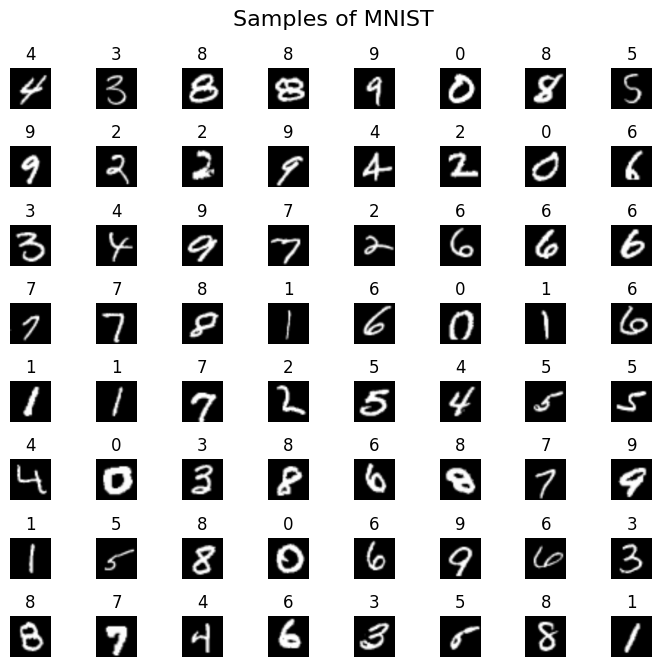

In [5]:
def show_images(images, labels=None, title=""):
    """ Show images with matplotlib. """
    fig = plt.figure(figsize=(7, 7))
    fig.suptitle(title, fontsize=16)

    l = len(images)
    rows = math.floor(math.sqrt(l))
    cols = math.ceil(l / rows)
    for i in range(len(images)):
        fig.add_subplot(rows, cols, i+1)  # add a subplot
        # prepare image for display
        image = images[i]
        image = image / 2 + 0.5  # convert tensor from [-1,1] to [0,1]
        image = image.numpy()  # convert from PyTorch tensor to NumPy format
        # Transpose tensor channels from (0,1,2) to (1,2,0).
        # Thus, shape (3, 64, 64) for image data transposed to (64, 64, 3).
        image = np.transpose(image, (1, 2, 0))
        plt.tight_layout()
        plt.imshow(image, cmap='gray')
        plt.axis("off")

        if labels is not None:
            if isinstance(labels[i], str):
                plt.title(labels[i])
            else:
                plt.title(labels[i].item())
    plt.show()

images, labels = next(iter(train_loader))
print(f"image size: {images[0].size()}")
show_images(images[:64], labels[:64], "Samples of MNIST")

# Model


We use a VAE to map images to a compact latent space, then run diffusion in that latent space.


### VAE (Encoder + Decoder)


In [6]:
class ConvVAE(nn.Module):
    '''Simple convolutional VAE for image inputs.'''

    def __init__(self, latent_ch: int = 4, in_channels: int = 1) -> None:
        super().__init__()
        self.in_channels = in_channels
        self.enc = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, latent_ch * 2, 3, padding=1),
        )
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(latent_ch, 64, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, in_channels, 3, padding=1),
            nn.Tanh(),
        )

    def encode(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        '''Return mu and logvar for the latent distribution.'''
        h = self.enc(x)
        mu, logvar = torch.chunk(h, 2, dim=1)
        return mu, logvar

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        '''Sample from N(mu, var) using the reparameterization trick.'''
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        '''Decode latents back to image space.'''
        return self.dec(z)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        '''Full VAE forward pass returning recon, mu, logvar.'''
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

    @torch.no_grad()
    def infer_latent_shape(self, image_shape, device=None):
        """
        image_shape: (C, H, W)
        """
        if device is None:
            device = next(self.parameters()).device

        x = torch.zeros(1, *image_shape, device=device)
        mu, _ = self.encode(x)
        return mu.shape[1:]   # (latent_ch, H', W')


def vae_loss(recon: torch.Tensor, x: torch.Tensor, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    '''Compute VAE loss = recon + KL.'''
    recon_loss = F.mse_loss(recon, x)
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + 1e-3 * kl




### Time embedding


In [7]:
class SinusoidalTimeEmb(nn.Module):
    '''Sinusoidal timestep embedding.'''

    def __init__(self, dim: int) -> None:
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        t = t.float()
        freqs = torch.exp(-math.log(10000) * torch.arange(0, half, device=t.device).float() / (half - 1))
        args = t[:, None] * freqs[None, :]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)
        return emb

### Conditional noise predictor (U-Net)


In [8]:
class ResBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, time_dim: int, groups: int = 8):
        super().__init__()
        self.in_ch = in_ch
        self.out_ch = out_ch

        self.norm1 = nn.GroupNorm(groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)

        self.time_proj = nn.Linear(time_dim, out_ch)

        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)

        self.skip = nn.Identity() if in_ch == out_ch else nn.Conv2d(in_ch, out_ch, kernel_size=1)

        self.act = nn.SiLU()

    def forward(self, x: torch.Tensor, t_emb: torch.Tensor) -> torch.Tensor:
        h = self.conv1(self.act(self.norm1(x)))

        # t_emb: (B, time_dim) -> (B, out_ch) -> (B, out_ch, 1, 1)
        t = self.time_proj(self.act(t_emb)).unsqueeze(-1).unsqueeze(-1)
        h = h + t

        h = self.conv2(self.act(self.norm2(h)))
        return h + self.skip(x)

In [ ]:
class AttentionBlock(nn.Module):
    def __init__(self, ch: int, num_heads: int = 4):
        super().__init__()
        self.norm = nn.GroupNorm(8 if ch % 8 == 0 else 1, ch)
        self.attn = nn.MultiheadAttention(ch, num_heads, batch_first=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        b, c, h, w = x.shape
        h_ = self.norm(x).view(b, c, h * w).transpose(1, 2)  # (b, hw, c)
        attn_out, _ = self.attn(h_, h_, h_)
        attn_out = attn_out.transpose(1, 2).view(b, c, h, w)
        return x + attn_out
    
class UNetLatent(nn.Module):
    """
    Tiny U-Net for latent maps with optional class conditioning.
    Multi-scale (2 downs), concat skips, 2 ResBlocks per level.
    """

    def __init__(
        self,
        in_ch: int = 4,
        base_ch: int = 96,
        time_dim: int = 256,
        num_classes: int = 10,
        ch_mults: Tuple[int, ...] = (2, 4),
        num_res_blocks: int = 2,
        use_checkpoint: bool = False,
    ) -> None:
        super().__init__()
        self.num_res_blocks = num_res_blocks
        self.use_checkpoint = use_checkpoint
        self.num_classes = num_classes

        self.time_mlp = nn.Sequential(
            SinusoidalTimeEmb(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.label_emb = nn.Embedding(num_classes, time_dim) if num_classes > 0 else None

        # stem
        self.in_conv = nn.Conv2d(in_ch, base_ch, 3, padding=1)

        # ----- Encoder -----
        enc_blocks = []
        downs = []
        chs = [base_ch]  # track skip channels
        curr_ch = base_ch

        for i, mult in enumerate(ch_mults):
            out_ch = base_ch * mult
            for _ in range(self.num_res_blocks):
                enc_blocks.append(ResBlock(curr_ch, out_ch, time_dim))
                curr_ch = out_ch
                chs.append(curr_ch)
            if i != len(ch_mults) - 1:
                downs.append(nn.Conv2d(curr_ch, curr_ch, 3, stride=2, padding=1))
                chs.append(curr_ch)
        # skip should not contain last feature
        chs.pop()

        self.enc_blocks = nn.ModuleList(enc_blocks)
        self.downs = nn.ModuleList(downs)

        # ----- Middle -----
        self.mid1 = ResBlock(curr_ch, curr_ch, time_dim)
        # self.mid_attn = AttentionBlock(curr_ch)
        self.mid2 = ResBlock(curr_ch, curr_ch, time_dim)

        # ----- Decoder -----
        dec_blocks = []
        ups = []
        for i, mult in reversed(list(enumerate(ch_mults))):
            out_ch = base_ch * mult
            for _ in range(self.num_res_blocks):
                skip_ch = chs.pop()  # match encoder saved channel
                dec_blocks.append(ResBlock(curr_ch + skip_ch, out_ch, time_dim))
                curr_ch = out_ch
            if i != 0:
                ups.append(nn.ConvTranspose2d(curr_ch, curr_ch, 4, stride=2, padding=1))

        self.dec_blocks = nn.ModuleList(dec_blocks)
        self.ups = nn.ModuleList(ups)

        # head
        self.out_norm = nn.GroupNorm(8 if curr_ch % 8 == 0 else 1, curr_ch)
        self.out_act = nn.SiLU()
        self.out_conv = nn.Conv2d(curr_ch, in_ch, 3, padding=1)

    def _maybe_ckpt(self, module, *args):
        if not self.use_checkpoint:
            return module(*args)
        return torch.utils.checkpoint.checkpoint(module, *args, use_reentrant=False)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: Optional[torch.Tensor] = None) -> torch.Tensor:
        """
        x: (N,4,H,W) latent
        t: (N,) or (N,1) timesteps
        y: (N,) class labels
        """
        t_emb = self.time_mlp(t)
        if self.label_emb is not None and y is not None:
            t_emb = t_emb + self.label_emb(y)

        h = self.in_conv(x)
        skips = [h]

        # Encoder: blocks + downsample
        bi = 0
        for i in range(len(self.downs) + 1):
            # each level has num_res_blocks
            for _ in range(self.num_res_blocks):
                h = self._maybe_ckpt(self.enc_blocks[bi], h, t_emb)
                bi += 1
                skips.append(h)
            if i < len(self.downs):
                h = self.downs[i](h)
                skips.append(h)
        # skip should not contain last feature
        skips.pop()

        # Middle
        h = self._maybe_ckpt(self.mid1, h, t_emb)
        # h = self._maybe_ckpt(self.mid_attn, h)
        h = self._maybe_ckpt(self.mid2, h, t_emb)

        # Decoder: upsample + concat skip + blocks
        di = 0
        for i in range(len(self.ups) + 1):
            for _ in range(self.num_res_blocks):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                h = self._maybe_ckpt(self.dec_blocks[di], h, t_emb)
                di += 1
            if i < len(self.ups):
                h = self.ups[i](h)

        h = self.out_conv(self.out_act(self.out_norm(h)))
        return h

### Latent diffusion core


In [86]:
class DiffusionCore(nn.Module):
    """
    Conditional Latent Diffusion Model (cLDM).
    """
    def __init__(
        self,
        n_steps=1000,
        start_beta=1e-4,
        end_beta=0.02,
        image_shape=(1, 28, 28),
        latent_channels=4,
        unet_base_ch=96,
        num_classes=10,
        vae: Optional[nn.Module] = None,
        unet: Optional[nn.Module] = None,
    ):
        super().__init__()
        self.n_steps = n_steps

        # ---- noise schedule: linear----
        betas = torch.linspace(start_beta, end_beta, n_steps)
        
        # ---- noise schedule: cosine ----
        # x = torch.arange(n_steps + 1, dtype=torch.float32)
        
        # # 1. Calculate the target cumulative alpha (signal decay curve)
        # s = 0.008
        # alphas_cumprod = torch.cos(((x / n_steps) + s) / (1 + s) * math.pi * 0.5) ** 2
        # alphas_cumprod = alphas_cumprod / alphas_cumprod[0]  # normalize to start at 1.0
        
        # # 2. Derive raw betas from the cumprod
        # betas = 1.0 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
        
        # # 3. THE CUTOFF: Clip beta to prevent math explosions
        # betas = torch.clip(betas, min=start_beta, max=0.9999)
        
        alphas = 1.0 - betas
        abar = torch.cumprod(alphas, dim=0)

        self.register_buffer("betas", betas)
        self.register_buffer("alphas", alphas)
        self.register_buffer("abar", abar)
        self.register_buffer("sqrt_abar", torch.sqrt(abar))
        self.register_buffer("sqrt_one_minus_abar", torch.sqrt(1.0 - abar))

        # ---- models ----
        self.unet = unet or UNetLatent(
            in_ch=latent_channels,
            base_ch=unet_base_ch,
            num_classes=num_classes,
        )   # εθ(z_t, t, y)
        self.vae = vae or ConvVAE(latent_channels, in_channels=image_shape[0])       # image <-> latent

        latent_shape = self.vae.infer_latent_shape(image_shape)
        self.latent_shape = latent_shape

    # --------------------------------------------------
    # q(z_t | z_0)
    # --------------------------------------------------
    def q_sample(self, z0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(z0)

        sa = self.sqrt_abar[t].view(-1, 1, 1, 1)
        so = self.sqrt_one_minus_abar[t].view(-1, 1, 1, 1)
        return sa * z0 + so * noise

    # --------------------------------------------------
    # training: predict epsilon
    # --------------------------------------------------
    def training_loss(self, x, y):
        """
        x: image
        y: condition label (class)
        """
        with torch.no_grad():
            mu, logvar = self.vae.encode(x)
            z0 = self.vae.reparameterize(mu, logvar)

        b = z0.shape[0]
        t = torch.randint(0, self.n_steps, (b,), device=z0.device)
        noise = torch.randn_like(z0)

        zt = self.q_sample(z0, t, noise)
        eps_pred = self.unet(zt, t, y)

        return F.mse_loss(eps_pred, noise)

    # --------------------------------------------------
    # sampling
    # --------------------------------------------------
    @torch.no_grad()
    def sample(self, batch_size, y):
        z = torch.randn(
            batch_size,
            *self.latent_shape,
            device=self.betas.device
        )

        for t in range(self.n_steps - 1, -1, -1):
            t_batch = torch.full((batch_size,), t, device=z.device)
            eps = self.unet(z, t_batch, y)

            beta = self.betas[t]
            alpha = self.alphas[t]
            abar = self.abar[t]

            mean = (z - beta / torch.sqrt(1 - abar) * eps) / torch.sqrt(alpha)

            if t > 0:
                z = mean + torch.sqrt(beta) * torch.randn_like(z)
            else:
                z = mean

        return self.vae.decode(z)
    
    # DDIM sampling
    @torch.no_grad()
    def ddim_sample(self, batch_size, y, num_steps = 50, eta=0.0):
        z = torch.randn(
            batch_size,
            *self.latent_shape,
            device=self.betas.device
        )
        steps = np.linspace(self.n_steps - 1, 0, num_steps, dtype=int)
        # pre-compute alpha_bar for the selected steps
        abar = self.abar[steps]                    # shape [num_steps]
        abar_next = torch.cat([abar[1:], torch.tensor([1.0]).to(abar)])
        
        for i, t in enumerate(steps):
            t_batch = torch.full((batch_size,), t, device=z.device)
            eps = self.unet(z, t_batch, y)

            alpha_bar_t = abar[i]
            alpha_bar_prev = abar_next[i]
            
            # predict x0
            x0_pred = (z - torch.sqrt(1 - alpha_bar_t) * eps) / torch.sqrt(alpha_bar_t)

            # compute mean for z_next
            dir_xt = torch.sqrt(1 - alpha_bar_prev) * eps
            mean = torch.sqrt(alpha_bar_prev) * x0_pred + dir_xt

            if i < num_steps - 1:
                sigma = eta * torch.sqrt((1 - alpha_bar_prev) / (1 - alpha_bar_t) * (1 - alpha_bar_t / alpha_bar_prev))
                noise = torch.randn_like(z)
                z = mean + sigma * noise
            else:
                z = mean
        
        return self.vae.decode(z)
        

# Train


We follow the standard **LDM training recipe**:

1. **Train the VAE** to compress images into a low-dimensional latent space.
2. **Show reconstructions** to verify the VAE learned meaningful latents.
3. **Freeze the VAE**, then **sample latents** and train the diffusion model in latent space.

This reduces memory and compute cost because diffusion runs on smaller latent tensors instead of full-resolution images.


#### Init Diffusion

In [56]:
core = DiffusionCore(
    n_steps=T,
    start_beta=beta_start,
    end_beta=beta_end,
    image_shape=(1, img_size, img_size),
    latent_channels=latent_channels,
    unet_base_ch=unet_base_ch,
    num_classes=num_classes,
).to(device)

print(f"[VAE]\n {core.vae}")
print(f"[Unet]\n {core.unet}")
print(f"[VAE latent shape]: {core.latent_shape}")

[VAE]
 ConvVAE(
  (enc): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (dec): Sequential(
    (0): ConvTranspose2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Tanh()
  )
)
[Unet]
 UNetLatent(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmb()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (label_emb): Embedding(10, 256)
  (in_conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_blocks): ModuleList(
    (0): ResBlock(
      (nor

### Train VAE


In [14]:
def train_vae(model: nn.Module, dataloader: DataLoader, n_epochs: int, lr: float) -> List[float]:
    '''Train VAE and return loss history.'''
    model.train()
    optimizer = AdamW(model.parameters(), lr=lr)
    losses: List[float] = []

    for epoch in range(n_epochs):
        pbar = tqdm(dataloader, desc=f"VAE Epoch {epoch + 1}/{n_epochs}")
        for x, _ in pbar:
            x = x.to(device)
            recon, mu, logvar = model(x)
            loss = vae_loss(recon, x, mu, logvar)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            pbar.set_postfix({"loss": loss.item()})
    return losses

In [ ]:
vae_losses = train_vae(core.vae, train_loader, n_epochs=n_epochs_vae, lr=lr_vae)

In [22]:
torch.save(core.vae.state_dict(), vae_store_path)

# Plot VAE loss values

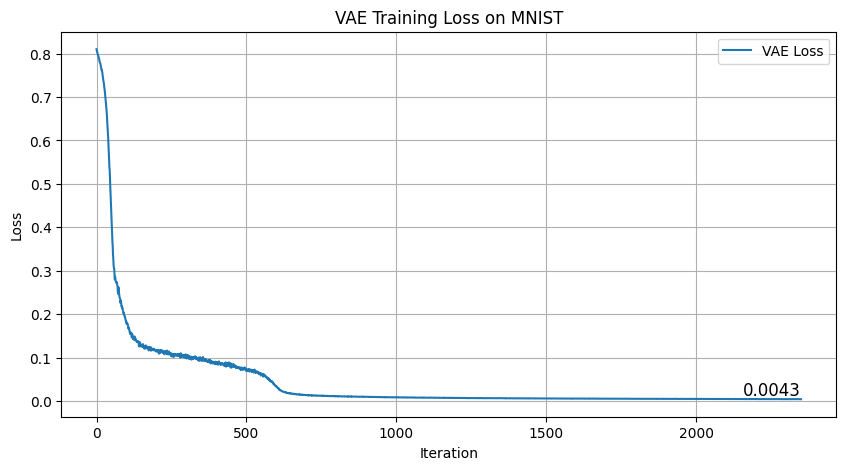

In [47]:
######################################################################################
# TODO: Plot the loss values of VAE for the MNIST dataset
######################################################################################
plt.figure(figsize=(10, 5))
plt.plot(vae_losses, label="VAE Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("VAE Training Loss on MNIST")
# plot final loss value as text
plt.text(len(vae_losses)-1, vae_losses[-1], f"{vae_losses[-1]:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right')
plt.grid()
plt.legend()
plt.show()

# Plot generated images in 5*5 grid


image size: torch.Size([1, 64, 64])
Original latent shape: torch.Size([25, 4, 16, 16])
Latent shape: torch.Size([25, 4, 16, 16])
Generated image shape: torch.Size([25, 1, 64, 64])


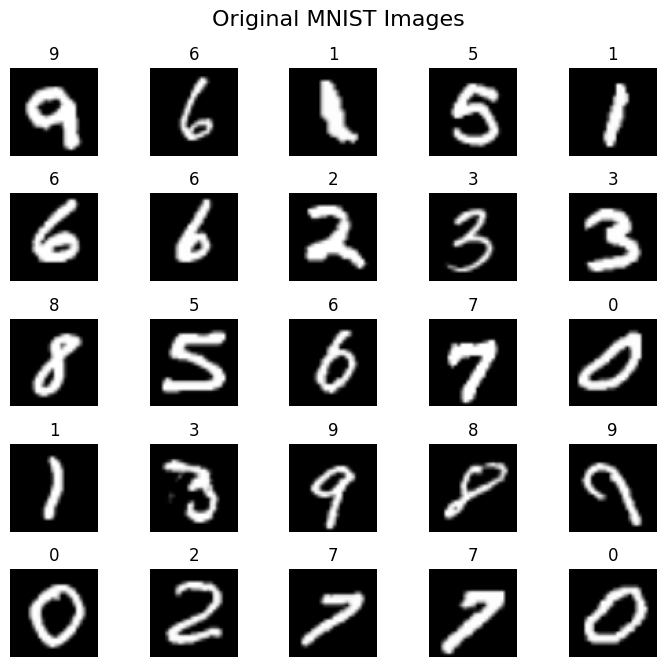

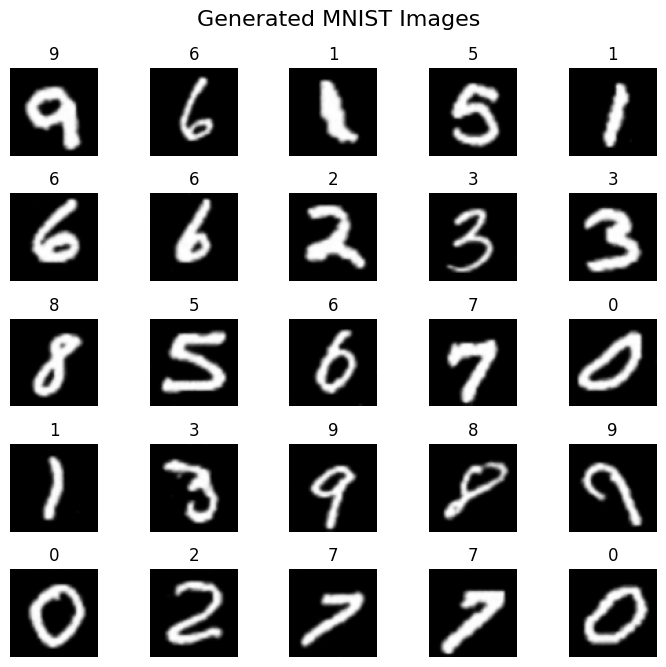

In [66]:
######################################################################################
# TODO: Store your generate images in 5*5 grid for the MNIST dataset
######################################################################################
images, labels = next(iter(train_loader))
print(f"image size: {images[0].size()}")

original = images[:25].to(device)
labels = labels[:25].to(device)

with torch.no_grad():
    mu, logvar = core.vae.encode(original)
    z0 = core.vae.reparameterize(mu, logvar)
    print(f"Original latent shape: {z0.shape}")
    print(f"Latent shape: {z0.shape}")
    
    generated = core.vae.decode(z0)
    print(f"Generated image shape: {generated.shape}")
    
    
show_images(images[:25].cpu(), labels[:25], "Original MNIST Images")
show_images(generated.cpu(), labels[:25], "Generated MNIST Images")

### Train latent diffusion


In [69]:
def train_ldm(
    core: DiffusionCore,
    dataloader: DataLoader,
    n_epochs: int,
    lr: float,
) -> List[float]:
    '''Train LDM in latent space using DiffusionCore.'''
    core.train()
    core.vae.eval()
    for p in core.vae.parameters():
        p.requires_grad = False

    optimizer = Adam(core.unet.parameters(), lr=lr)
    losses: List[float] = []

    for epoch in range(n_epochs):
        pbar = tqdm(dataloader, desc=f"LDM Epoch {epoch + 1}/{n_epochs}")
        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)

            loss = core.training_loss(x, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())
            pbar.set_postfix({"loss": loss.item()})
    return losses

In [72]:
ldm_losses = train_ldm(core, train_loader, n_epochs=n_epochs_ldm, lr=lr_ldm)

LDM Epoch 15/15: 100%|██████████| 235/235 [00:14<00:00, 15.78it/s, loss=0.201]


In [73]:
torch.save(core.unet.state_dict(), unet_store_path)
torch.save(core.state_dict(), core_store_path)

# Plot LDM loss values

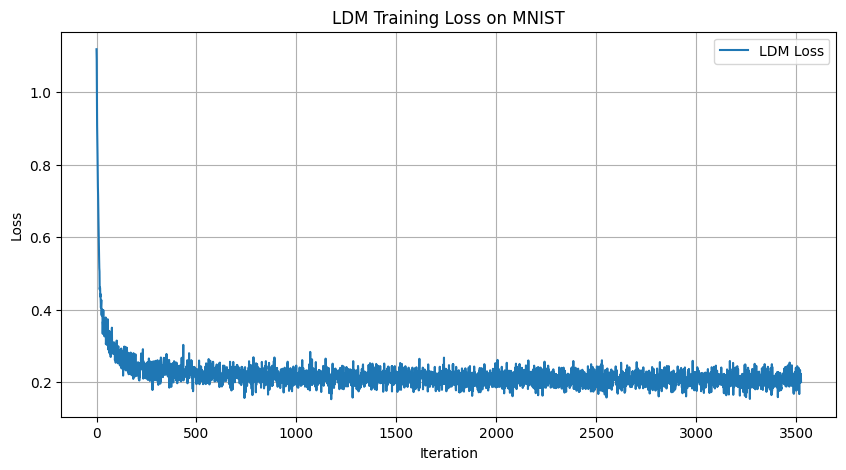

In [74]:
######################################################################################
# TODO: Plot the loss values of LDM for the MNIST dataset
######################################################################################
plt.figure(figsize=(10, 5))
plt.plot(ldm_losses, label="LDM Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("LDM Training Loss on MNIST")
plt.grid()
plt.legend()
plt.show()

# Generation


### Load the trained model


In [75]:
core = DiffusionCore(
    n_steps=T,
    start_beta=beta_start,
    end_beta=beta_end,
    image_shape=(1, img_size, img_size),
    latent_channels=latent_channels,
    unet_base_ch=unet_base_ch,
    num_classes=num_classes,
).to(device)
core.vae.load_state_dict(torch.load(vae_store_path, map_location=device))
core.unet.load_state_dict(torch.load(unet_store_path, map_location=device))
core.load_state_dict(torch.load(core_store_path, map_location=device))
core.eval()

DiffusionCore(
  (unet): UNetLatent(
    (time_mlp): Sequential(
      (0): SinusoidalTimeEmb()
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): SiLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (label_emb): Embedding(10, 256)
    (in_conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (enc_blocks): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_proj): Linear(in_features=256, out_features=128, bias=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU()
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (conv1): Conv2d(128, 128, kernel_size=(3

### Plot generated images in 5*5 grid


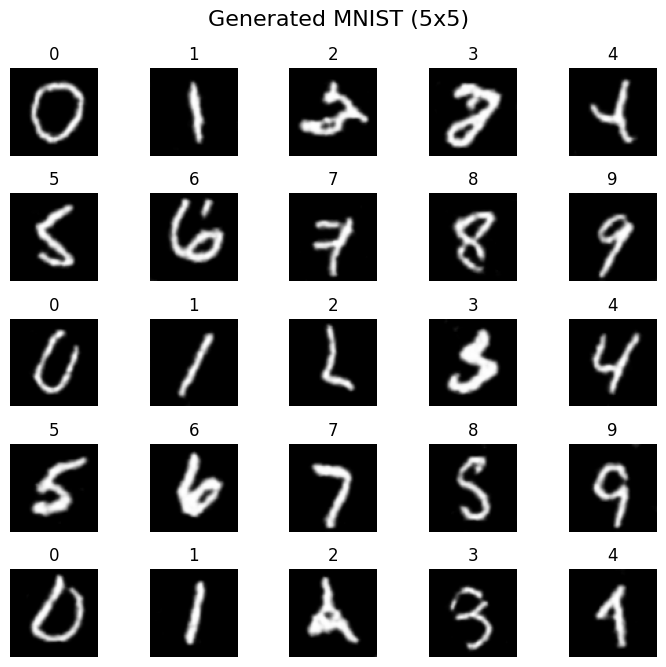

In [83]:
with torch.no_grad():
    y = torch.arange(25, device=device) % num_classes
    gen_images = core.sample(batch_size=25, y=y).cpu()
show_images(gen_images, labels=y.cpu(), title="Generated MNIST (5x5)")

### Show transition: noise -> image


In [84]:
@torch.no_grad()
def sample_with_history(
    core: DiffusionCore,
    batch_size: int,
    y: torch.Tensor,
    n_frames: int = 16,
) -> List[torch.Tensor]:
    """Run reverse diffusion and keep decoded snapshots from noise to image."""
    z = torch.randn(batch_size, *core.latent_shape, device=device)
    keep_ts = torch.linspace(core.n_steps - 1, 0, steps=n_frames, device=device).long()
    keep_set = set(keep_ts.tolist())
    frames: Dict[int, torch.Tensor] = {}

    for t in range(core.n_steps - 1, -1, -1):
        t_batch = torch.full((batch_size,), t, device=device, dtype=torch.long)
        eps = core.unet(z, t_batch, y)

        beta = core.betas[t]
        alpha = core.alphas[t]
        abar = core.abar[t]
        mean = (z - beta / torch.sqrt(1 - abar) * eps) / torch.sqrt(alpha)
        z = mean + torch.sqrt(beta) * torch.randn_like(z) if t > 0 else mean

        if t in keep_set:
            frames[t] = core.vae.decode(z).cpu()

    # Return in noise->image order.
    return [frames[t.item()] for t in keep_ts]

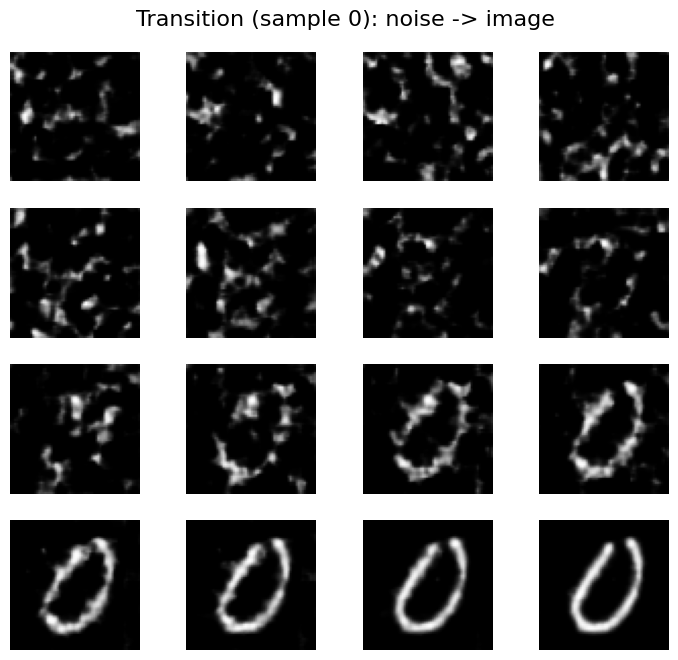

In [85]:
with torch.no_grad():
    y16 = torch.arange(16, device=device) % num_classes
    hist = sample_with_history(core, batch_size=16, y=y16, n_frames=16)

# Visualize one sample across timesteps (left: noisy, right: clean).
transition_strip = torch.stack([frame[0] for frame in hist], dim=0)
show_images(transition_strip, title="Transition (sample 0): noise -> image")

# It's your turn


You need to train the latent diffusion model on the CelebA 64x64 subset and experiment with different attributes or CFG scales.


## CelebA experiment setup
- Condition on one attribute: Smiling (0/1)
- Train RGB VAE + latent diffusion at 64x64

In [ ]:
celeba_img_size = 64
celeba_batch_size = 128
celeba_n_epochs_vae = 10
celeba_n_epochs_ldm = 15
celeba_lr_vae = 1e-4
celeba_lr_ldm = 1e-4
celeba_num_classes = 2

In [39]:
celeba_vae_store_path = "vae_celeba.pt"
celeba_unet_store_path = "unet_celeba.pt"
celeba_core_store_path = "core_celeba.pt"
celeba_dataset_path = f"{workspace_dir}/celeba_dataset"

In [40]:
class CelebASmilingDataset(torch.utils.data.Dataset):
    """Wrap CelebA to return (image, smiling_label)."""

    def __init__(self, root: str, split: str, transform=None):
        self.base = torchvision.datasets.CelebA(
            root=root,
            split=split,
            target_type="attr",
            transform=transform,
            download=True,
        )
        self.attr_names = self.base.attr_names
        self.smiling_idx = self.attr_names.index("Smiling")

    def __len__(self) -> int:
        return len(self.base)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        image, attrs = self.base[idx]
        smiling = attrs[self.smiling_idx].long()
        return image, smiling

In [41]:
celeba_transform = Compose([
    Resize((celeba_img_size, celeba_img_size)),
    ToTensor(),
    Lambda(lambda x: (x - 0.5) * 2),
])
celeba_dataset = CelebASmilingDataset(
    root=celeba_dataset_path,
    split="train",
    transform=celeba_transform,
)
celeba_loader = DataLoader(
    celeba_dataset,
    batch_size=celeba_batch_size,
    shuffle=True,
    pin_memory=torch.cuda.is_available(),
)
print(celeba_loader.dataset.base)

Dataset CelebA
    Number of datapoints: 162770
    Root location: ./celeba_dataset
    Target type: ['attr']
    Split: train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Lambda()
           )


image size: torch.Size([3, 64, 64])


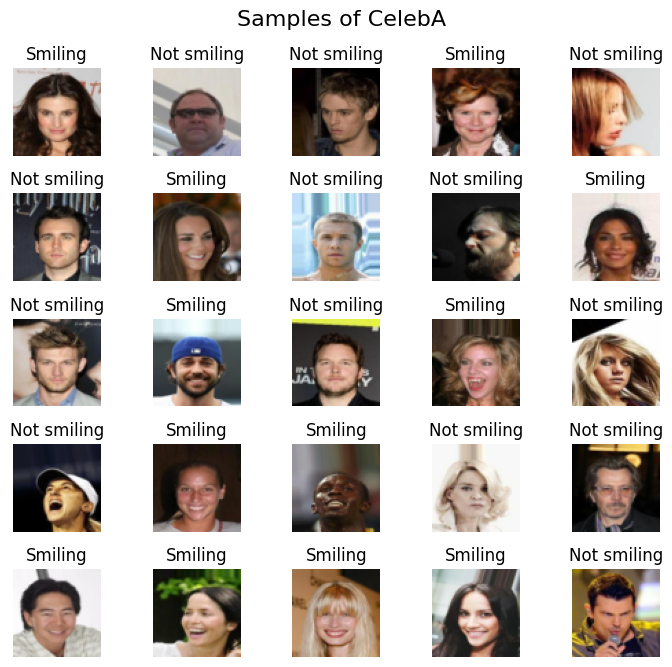

In [45]:
images, labels = next(iter(celeba_loader))
lookup = {0: "Not smiling", 1: "Smiling"}
print(f"image size: {images[0].size()}")
show_images(
    images[:25],
    [lookup[x.cpu().item()] for x in labels[:25]],
    "Samples of CelebA"
)

In [46]:
celeba_core = DiffusionCore(
    n_steps=T,
    start_beta=beta_start,
    end_beta=beta_end,
    image_shape=(3, celeba_img_size, celeba_img_size),
    latent_channels=latent_channels,
    unet_base_ch=unet_base_ch,
    num_classes=celeba_num_classes,
).to(device)

print(f"[VAE]\n {celeba_core.vae}")
print(f"[Unet]\n {celeba_core.unet}")
print(f"[VAE latent shape]: {celeba_core.latent_shape}")

[VAE]
 ConvVAE(
  (enc): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (dec): Sequential(
    (0): ConvTranspose2d(4, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): Tanh()
  )
)
[Unet]
 UNetLatent(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmb()
    (1): Linear(in_features=256, out_features=256, bias=True)
    (2): SiLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
  )
  (label_emb): Embedding(2, 256)
  (in_conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (enc_blocks): ModuleList(
    (0): ResBlock(
      (norm

VAE Epoch 10/10: 100%|██████████| 1272/1272 [01:04<00:00, 19.82it/s, loss=0.00757]


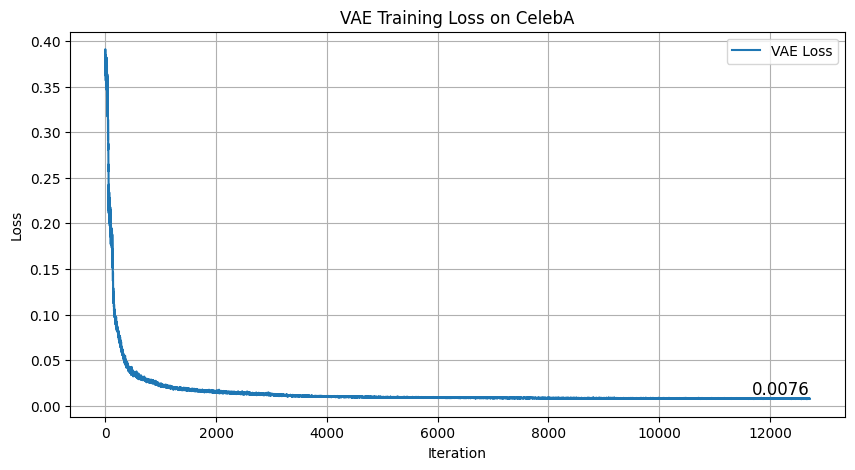

In [ ]:
######################################################################################
# TODO: Design the cLDM for the CelebA dataset and start the training
# Remember to resize the images to 64x64
######################################################################################

vae_losses_celeba = train_vae(celeba_core.vae, celeba_loader, n_epochs=celeba_n_epochs_vae, lr=celeba_lr_vae)


In [29]:
torch.save(celeba_core.vae.state_dict(), celeba_vae_store_path)

image size: torch.Size([3, 64, 64])
Original latent shape: torch.Size([25, 4, 16, 16])
Latent shape: torch.Size([25, 4, 16, 16])
Generated image shape: torch.Size([25, 3, 64, 64])


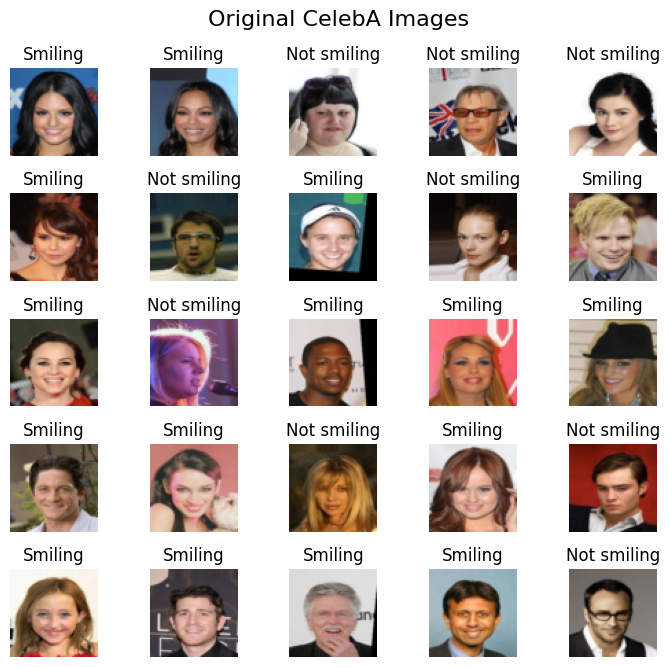

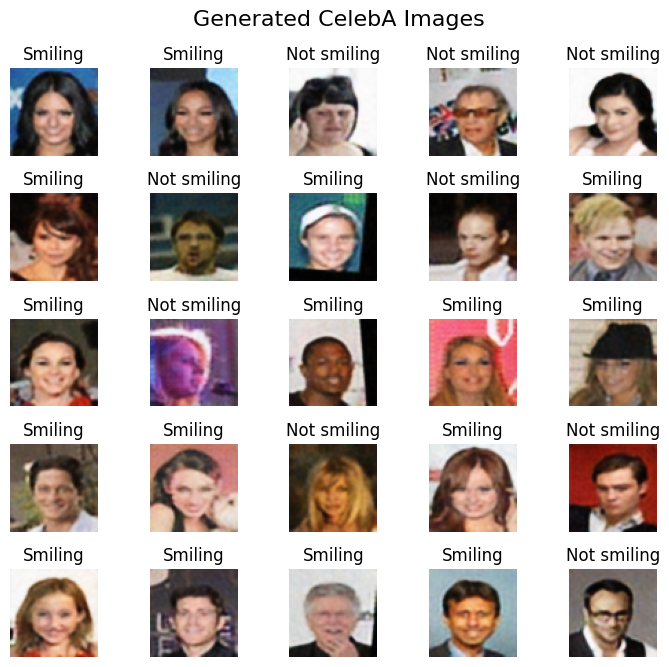

In [28]:
images, labels = next(iter(celeba_loader))
print(f"image size: {images[0].size()}")
original = images[:25].to(device)
smile_labels = ["Not smiling" if x == 0 else "Smiling" for x in labels[:25]]

with torch.no_grad():
    mu, logvar = celeba_core.vae.encode(original)
    z0 = celeba_core.vae.reparameterize(mu, logvar)
    print(f"Original latent shape: {z0.shape}")
    print(f"Latent shape: {z0.shape}")

    generated = celeba_core.vae.decode(z0)
    print(f"Generated image shape: {generated.shape}")

show_images(original.cpu(), smile_labels, "Original CelebA Images")
show_images(generated.cpu(), smile_labels, "Generated CelebA Images")

LDM Epoch 15/15: 100%|██████████| 1272/1272 [01:24<00:00, 14.98it/s, loss=0.186] 


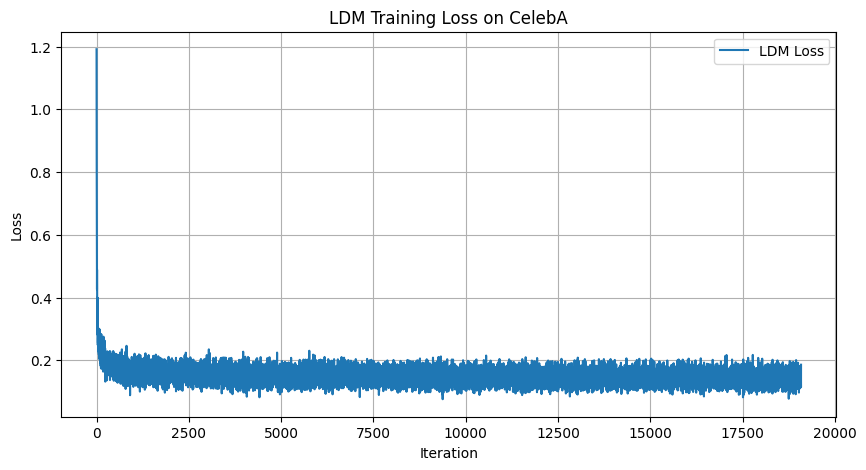

In [30]:
ldm_losses_celeba = train_ldm(celeba_core, celeba_loader, n_epochs=celeba_n_epochs_ldm, lr=celeba_lr_ldm)

In [32]:
torch.save(celeba_core.unet.state_dict(), celeba_unet_store_path)
torch.save(celeba_core.state_dict(), celeba_core_store_path)

# Plot loss values


CelebA loss curves


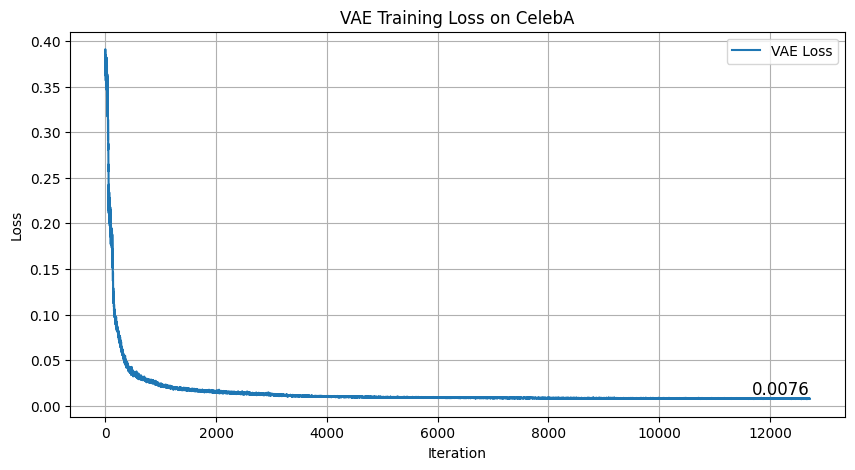

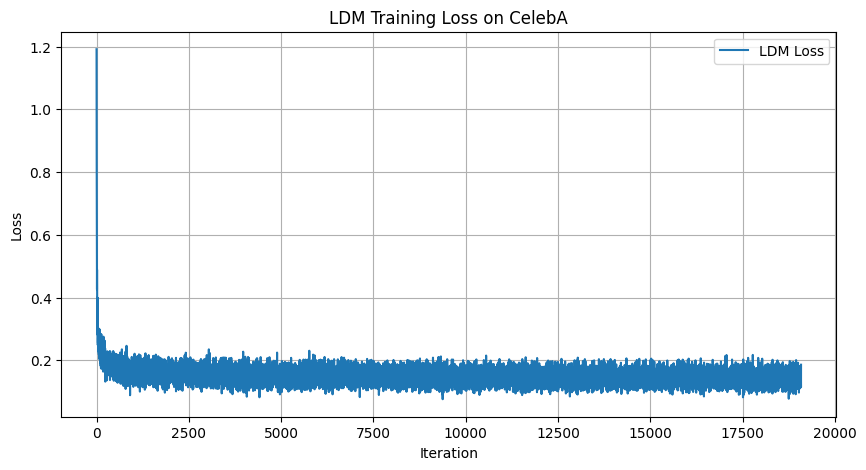

In [34]:
######################################################################################
# TODO: Plot the loss values of VAE and LDM for the CelebA dataset
######################################################################################
plt.figure(figsize=(10, 5))
plt.plot(vae_losses_celeba, label="VAE Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("VAE Training Loss on CelebA")
# plot final loss value as text
plt.text(len(vae_losses_celeba)-1, vae_losses_celeba[-1], f"{vae_losses_celeba[-1]:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right')
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(ldm_losses_celeba, label="LDM Loss")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("LDM Training Loss on CelebA")
plt.grid()
plt.legend()
plt.show()

In [47]:
celeba_core = DiffusionCore(
    n_steps=T,
    start_beta=beta_start,
    end_beta=beta_end,
    image_shape=(3, celeba_img_size, celeba_img_size),
    latent_channels=latent_channels,
    unet_base_ch=unet_base_ch,
    num_classes=celeba_num_classes,
).to(device)
celeba_core.vae.load_state_dict(torch.load(celeba_vae_store_path, map_location=device))
celeba_core.unet.load_state_dict(torch.load(celeba_unet_store_path, map_location=device))
celeba_core.load_state_dict(torch.load(celeba_core_store_path, map_location=device))
celeba_core.eval()

DiffusionCore(
  (unet): UNetLatent(
    (time_mlp): Sequential(
      (0): SinusoidalTimeEmb()
      (1): Linear(in_features=256, out_features=256, bias=True)
      (2): SiLU()
      (3): Linear(in_features=256, out_features=256, bias=True)
    )
    (label_emb): Embedding(2, 256)
    (in_conv): Conv2d(4, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (enc_blocks): ModuleList(
      (0): ResBlock(
        (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (time_proj): Linear(in_features=256, out_features=128, bias=True)
        (norm2): GroupNorm(8, 128, eps=1e-05, affine=True)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (skip): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU()
      )
      (1): ResBlock(
        (norm1): GroupNorm(8, 128, eps=1e-05, affine=True)
        (conv1): Conv2d(128, 128, kernel_size=(3,

# Plot generated images in 5*5 grid


Generate CelebA samples in 5x5 grid
Label mapping: 0=Not Smiling, 1=Smiling


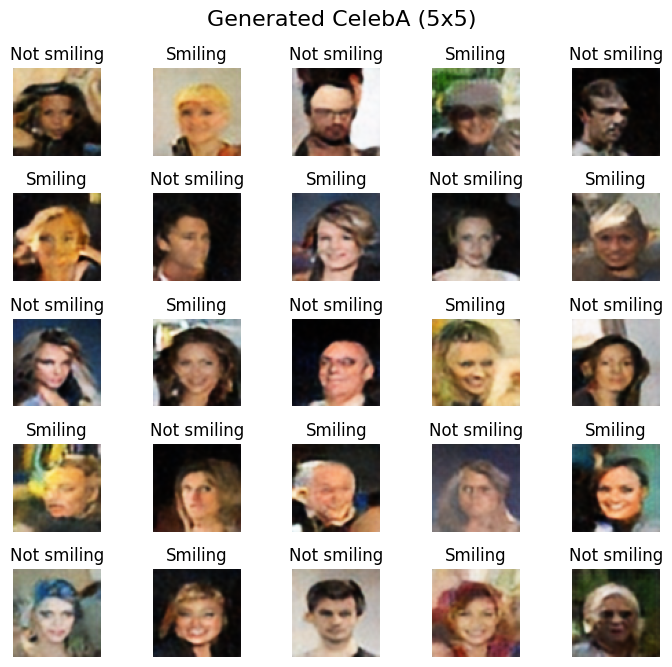

In [49]:
######################################################################################
# TODO: Store your generate images in 5*5 grid for the CelebA dataset
######################################################################################
lookup = {0: "Not smiling", 1: "Smiling"}
with torch.no_grad():
    y = torch.arange(25, device=device) % celeba_num_classes
    gen_images = celeba_core.sample(batch_size=25, y=y).cpu()
show_images(gen_images, labels=[lookup[int(x)] for x in y.cpu()], title="Generated CelebA (5x5)")

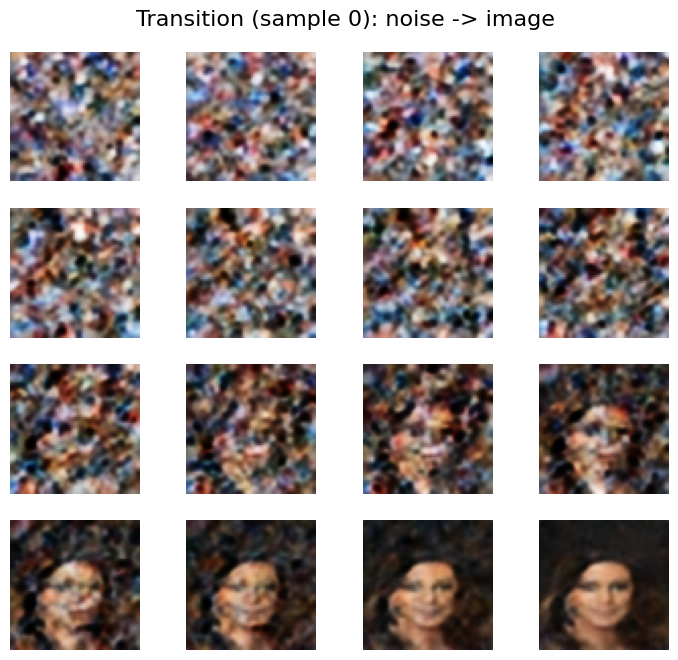

In [52]:
# The transition of CelebA. With VAE, the transition is not from pure noises.
with torch.no_grad():
    y16 = torch.arange(16, device=device) % celeba_num_classes
    hist = sample_with_history(celeba_core, batch_size=16, y=y16, n_frames=16)
transition_strip = torch.stack([frame[0] for frame in hist], dim=0)
show_images(transition_strip, title="Transition (sample 0): noise -> image")

# FID for CelebA Smiling

This FID section evaluates CelebA Smiling only:
- 0 = Not smiling
- 1 = Smiling

If your model uses more than two condition labels, this evaluator still only samples labels 0 and 1 and interprets them as Not smiling/Smiling. Do not use this score to judge other attributes or extra classes unless you rewrite the dataset labels and condition mapping consistently.

Warning: this assumes the model was trained with label 0 as Not smiling and label 1 as Smiling. If your label mapping is different, the FID result is invalid even though the code still runs.

Conditional FID is computed separately for Smiling=0 and Smiling=1. Fake images are generated with the same label as the real images being compared. Do not mix both labels before computing conditional FID, because that hides whether one condition is much worse than the other.

The overall FID below is the real-sample-weighted average of the two conditional FID scores. It is a summary number only; always inspect the two per-condition scores as well.


In [53]:
fid_num_samples = 5_000 # cannot change number of samples
fid_batch_size = 128 # you can change it if run out of VRAM


def _fid_preprocess(images: torch.Tensor) -> torch.Tensor:
    """Prepare images for FID as float tensors in [0, 1] with size 299x299."""
    images = images.float()
    images = (images + 1) / 2
    images = images.clamp(0, 1)
    if images.shape[1] == 1:
        images = images.repeat(1, 3, 1, 1)
    images = F.interpolate(
        images,
        size=(299, 299),
        mode="bilinear",
        align_corners=False,
    )
    return images


@torch.no_grad()
def _sample_celeba_condition(
    core: DiffusionCore,
    n_samples: int,
    condition_label: int,
) -> torch.Tensor:
    """Generate CelebA samples for one Smiling condition label."""
    y = torch.full(
        (n_samples,),
        condition_label,
        device=next(core.parameters()).device,
        dtype=torch.long,
    )
    return core.sample(batch_size=n_samples, y=y)


def _compute_smiling_fid_for_label(
    core: DiffusionCore,
    real_loader: DataLoader,
    condition_label: int,
    num_samples: int,
    batch_size: int,
) -> Dict[str, float]:
    """Compute conditional FID for one CelebA Smiling label."""
    fid = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
    core.eval()

    real_seen = 0
    for batch, labels in real_loader:
        mask = labels == condition_label
        if not mask.any():
            continue

        batch = batch[mask]
        remaining = num_samples - real_seen
        if batch.shape[0] > remaining:
            batch = batch[:remaining]

        batch = _fid_preprocess(batch.to(device))
        fid.update(batch, real=True)
        real_seen += batch.shape[0]

        if real_seen >= num_samples:
            break

    if real_seen == 0:
        raise ValueError(
            f"No real CelebA samples found for Smiling={condition_label}. "
            "Check that celeba_loader returns the Smiling label."
        )

    if real_seen < num_samples:
        print(
            f"Warning: only found {real_seen} real images for "
            f"Smiling={condition_label}; requested {num_samples}."
        )

    fake_seen = 0
    while fake_seen < num_samples:
        cur_bs = min(batch_size, num_samples - fake_seen)
        fake = _sample_celeba_condition(core, cur_bs, condition_label)
        fake = _fid_preprocess(fake)
        fid.update(fake, real=False)
        fake_seen += cur_bs

    return {
        "FID": float(fid.compute().item()),
        "Real Samples": real_seen,
        "Fake Samples": fake_seen,
    }


def evaluate_celeba_smiling_fid(
    core: DiffusionCore,
    real_loader: DataLoader,
    num_samples: int = fid_num_samples,
    batch_size: int = fid_batch_size,
) -> Tuple[List[Dict[str, float]], float]:
    """Evaluate conditional FID for Not smiling and Smiling CelebA samples."""
    model_weight = sum(p.numel() for p in core.parameters())
    results: List[Dict[str, float]] = []

    for condition_label, condition_name in [(0, "Not smiling"), (1, "Smiling")]:
        metrics = _compute_smiling_fid_for_label(
            core=core,
            real_loader=real_loader,
            condition_label=condition_label,
            num_samples=num_samples,
            batch_size=batch_size,
        )
        results.append({
            "Attribute": "Smiling",
            "Condition": f"{condition_label} {condition_name}",
            "FID": metrics["FID"],
            "Real Samples": metrics["Real Samples"],
            "Fake Samples": metrics["Fake Samples"],
            "Model Weight (params)": model_weight,
        })

    total_real = sum(row["Real Samples"] for row in results)
    overall_fid = sum(row["FID"] * row["Real Samples"] for row in results) / total_real
    results.append({
        "Attribute": "Smiling",
        "Condition": "Overall weighted",
        "FID": overall_fid,
        "Real Samples": total_real,
        "Fake Samples": sum(row["Fake Samples"] for row in results),
        "Model Weight (params)": model_weight,
    })

    return results, overall_fid


# Usage:
# Make sure celeba_loader returns (image, smiling_label), where
# 0 means Not smiling and 1 means Smiling. Then run this cell after
# loading the trained CelebA conditional LDM into celeba_core.
fid_results, celeba_smiling_overall_fid = evaluate_celeba_smiling_fid(
    core=celeba_core,
    real_loader=celeba_loader,
    num_samples=fid_num_samples,
    batch_size=fid_batch_size,
)

try:
    import pandas as pd
    from IPython.display import display

    display(pd.DataFrame(fid_results))
except ImportError:
    for row in fid_results:
        print(row)
    print(f"Overall weighted CelebA Smiling FID: {celeba_smiling_overall_fid:.4f}")

,Attribute,Condition,FID,Real Samples,Fake Samples,Model Weight (params)
0,Smiling,0 Not smiling,75.880180,5000,5000,11506767
1,Smiling,1 Smiling,70.414047,5000,5000,11506767
2,Smiling,Overall weighted,73.147114,10000,10000,11506767


Copy the Overall weighted (72.3712043762207) and paste to your report.

|index|Attribute|Condition|FID|Real Samples|Fake Samples|Model Weight \(params\)|
|---|---|---|---|---|---|---|
|0|Smiling|0 Not smiling|75\.51207733154297|5000|5000|11506767|
|1|Smiling|1 Smiling|69\.23033142089844|5000|5000|11506767|
|2|Smiling|Overall weighted|72\.3712043762207|10000|10000|11506767|

In [ ]:
	Attribute	Condition	FID	Real Samples	Fake Samples	Model Weight (params)
0	Smiling	0 Not smiling	75.880180	5000	5000	11506767
1	Smiling	1 Smiling	70.414047	5000	5000	11506767
2	Smiling	Overall weighted	73.147114	10000	10000	11506767
